# This code can be used to perform sanity checks that preprocessing was done correctly
### It checks the following:
1. Plots a FC matrix for visual check
2. Higher within than between FC for the DMN
3. Anti correlation between high and low attention networks

In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os.path as osp
import os

In [21]:
PRJ = 'test_preproc'
task = 'rest' #task is required
run = '' #run is optional, if you do not want run just put '' 

In [22]:
PRJ_DIR = f'/project/mdrosenberg/IG/{PRJ}'

In [41]:
def load_netcc(path,roi_names=None):
    sfc = pd.read_csv(path,sep='\t',comment='#', header=0)
    sfc = sfc.drop(0,axis=0) #drop first row that is just ROI labels 
    sfc_Z = sfc.tail(len(sfc.columns)) #get the bottom half (the z-scored matrix)

    np.fill_diagonal(sfc_Z.values, 1) #set diangonal to 1
    sfc_Z.index = sfc_Z.columns
    if roi_names is not None:
        sfc_Z.index = roi_names
        sfc_Z.columns = roi_names
    return sfc_Z


In [42]:
def get_sub_list(DATA_DIR):
    import os

    # Get the list of files in the current directory
    files = os.listdir(DATA_DIR)
    
    # Sort the files by modification time
    sorted_files = sorted(files)
    
    sub_list = []

    for i, filename in enumerate(sorted_files):
        if filename[0:3] == 'sub':
            sub = filename
            sub_folder = osp.join(DATA_DIR, filename)
            if os.path.isdir(sub_folder):
                ses_count = 0
                ses_nums = []

                for sub_filename in os.listdir(sub_folder):
                    if sub_filename[0:3] == 'ses':
                        ses_count += 1
                        ses_nums.append(sub_filename)
                        
                if ses_count > 0:
                    for s in range(ses_count):
                        sub_list.append((sub,ses_nums[s]))
                else:
                    sub_list.append(sub)
    return sub_list

In [43]:
sub_list = get_sub_list(f'{PRJ_DIR}/derivatives/preprocessed/')

In [44]:
sub_list

['sub-117']

# 1. Plot FC matrix for visual QC 
Select the subject first
NOTE: if the data has session numbers as well, that needs to be updated in the paths below

In [45]:
sub = sub_list[0]
#ses = 'ses-01'

In [46]:
#load relevant files 
network_labels_path = '/project/mdrosenberg/IG/preprocessing/masks/Shen_network_labels.pkl'
with open(network_labels_path, 'rb') as file:
            network_labels = pickle.load(file)['Shen_network_labels']

canonical_mask_path = '/project/mdrosenberg/IG/preprocessing/masks/canonical_mask.pkl'
with open(canonical_mask_path, 'rb') as file:
            canonical_mask = pickle.load(file)['canonical_mask']

network_names = ['Medial frontal','Frontoparietal','Default mode','Subcortical-cerebellum','Motor','Visual I','Visual II','Visual association']

In [47]:
netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/4_{sub}_task-{task}_LPI_000.netcc')
FC = load_netcc(netcc_path)

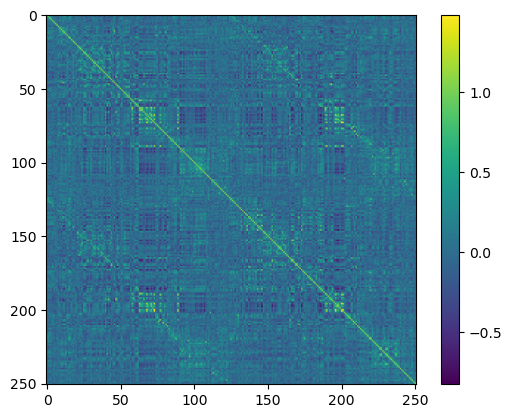

In [48]:
#TO DO: sort by network and make plot formal 
plt.imshow(FC)
plt.colorbar()

# 2. Greater within than between FC for DMN and FP

In [49]:
def summarize_net_con(FC, canonical_mask, net1, net2):
    #get indices
    ind = canonical_mask[net1,net2]

    #select networks from FC
    net_FC = ind*FC

    #create plot of network FC to check
    #plt.imshow(net_FC)

    num_nodes = ind.sum().sum()
    avg_net_FC = net_FC.sum().sum()/num_nodes

    return avg_net_FC
    

In [52]:
def fill_missing_rois(FC):
    # Convert column names to integers (assumes they are strings of ints)
    existing_rois = [int(col) for col in FC.columns]
    all_rois = list(range(1, 269))  # 1 to 268 inclusive
    missing = sorted(set(all_rois) - set(existing_rois))  # sort to maintain order

    # add missing rows
    for roi in missing:
        if roi > 99:
            label = f'{roi}' # column label format
        else:
            label = f'0{roi}'  
            
        FC[label] = np.nan  # add column with NaNs

    # insert rows
    FC = FC.T
    for roi in missing:
        if roi > 99:
            label = f'{roi}'
        else:
            label = f'0{roi}'
        FC[label] = np.nan  # add missing row

        #make columns and rows strings
        FC.columns = FC.columns.map(lambda x: f'{int(x):03d}')
        FC.index = FC.index.map(lambda x: f'{int(x):03d}')

        # reorder
        ordered_labels = [f'{roi:03d}' for roi in range(1, 269)]
        FC = FC.reindex(index=ordered_labels, columns=ordered_labels)

    return FC

In [53]:
store = pd.DataFrame(columns=['DMN-DMN','DMN-FP'])
row = 0

for sub in sub_list:
    netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/4_{sub}_task-{task}_LPI_000.netcc')
    FC = load_netcc(netcc_path)
    FC = fill_missing_rois(FC)

    DMN_DMN = summarize_net_con(FC, canonical_mask, 2, 2)
    DMN_FP = summarize_net_con(FC, canonical_mask, 2, 1)

    store.loc[row,'DMN-DMN'] = DMN_DMN
    store.loc[row,'DMN-FP'] = DMN_FP
    row += 1


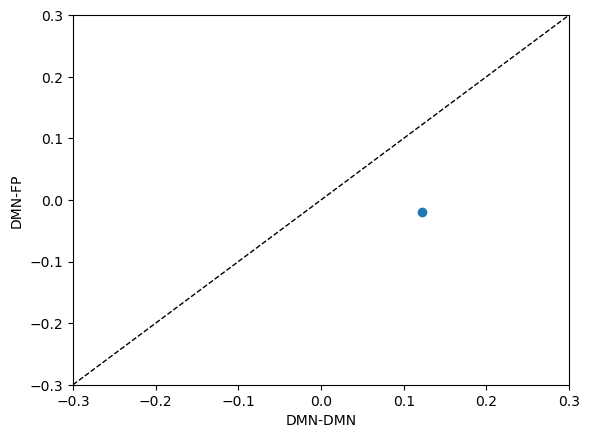

In [57]:
plt.scatter(store['DMN-DMN'], store['DMN-FP'])
plt.xlabel('DMN-DMN')
plt.ylabel('DMN-FP')

ax = plt.gca()
ax.set_xlim([-0.3,0.3])
ax.set_ylim([-0.3,0.3])

x_vals = [0, 1]  # Identity line range
y_vals = [0, 1]  # Identity line values

# Add the identity line
plt.plot(x_vals, y_vals, transform=plt.gca().transAxes, color='k', linestyle='--', linewidth=1)

### To confirm that this is correct: All dopts in the plot above should be BELOW the identity line

# 3. Anti-correlation between high and low attention networks

In [58]:
#load relevant files 
saCPM = '/project/mdrosenberg/IG/preprocessing/masks/saCPM.pkl'
with open(saCPM, 'rb') as file:
            high_attention_mask = pickle.load(file)['high_attention_mask']

with open(saCPM, 'rb') as file:  
            low_attention_mask = pickle.load(file)['low_attention_mask']

In [60]:
atten = pd.DataFrame(columns=['high_atten','low_atten'])
row = 0

for sub in sub_list:
    netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/4_{sub}_task-{task}_LPI_000.netcc')
    FC = load_netcc(netcc_path)
    FC = fill_missing_rois(FC)

    #high
    high_FC = high_attention_mask*FC
    high = high_FC.sum().sum()/(high_attention_mask.sum().sum())

    #low
    low_FC = low_attention_mask*FC
    low = low_FC.sum().sum()/(low_attention_mask.sum().sum())
    
    atten.loc[row,'high_atten'] = high
    atten.loc[row,'low_atten'] = low
    row += 1

,high_atten,low_atten
high_atten,NaN,NaN
low_atten,NaN,NaN


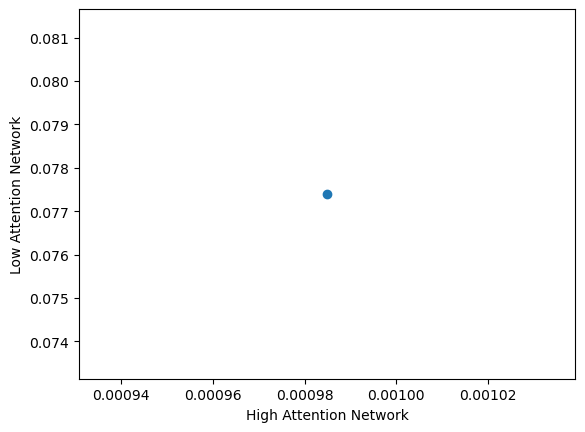

In [61]:
plt.scatter(atten['high_atten'], atten['low_atten'])
plt.xlabel('High Attention Network')
plt.ylabel('Low Attention Network')

atten.corr()


### To confirm this result is good, the correlation between high and low should be negative 